**Some changes to the game theory project**

In [1]:
using Statistics

Existing functions and model

In [2]:
# pos: list of the position (x,y) of every bird
# v: magnitude of the velocity
# L: size of the box where the birds are confined

function new_position!(pos, dir, v, L)
    for i in 1:length(dir)
        dx = v * cos(dir[i]) # update on x-direction
        pos[1,i] = mod(pos[1,i] + dx, L)
        dy = v * sin(dir[i]) # update on y-direction
        pos[2,i] = mod(pos[2,i] + dy, L)
    end
end

new_position! (generic function with 1 method)

In [3]:
# grid: vector that stores which bird is in every cell
#    for example, if the grid is 3x3 and there are four birds in the configuration
#    | 1  -  - |
#    | -  -  2 |
#    | -  3  - |
#    we will have grid = [[1],[],[],[],[],[2],[],[3],[]]
#    ! Be aware that it is possible to have zero o more than one bird in a single cell
# R: radius of interaction (it defines the linear size of each square cell)
# n: number of cells per side

function grid!(pos, grid::Vector{Vector{Int}}, R, cells, n)
    # Replaces empty!.(grid)
    for g in grid
        empty!(g)
    end
    
    for i in 1:size(pos,2) 
        col = Int(floor(pos[1,i]/R)) + 1
        row = Int(floor(pos[2,i]/R)) + 1
        idx = row + n*(col-1)
        cells[i] = idx 
        push!(grid[idx], i)
    end
end

grid! (generic function with 1 method)

In [4]:
# cell_neig: vector that stores in every index (corresponding to every cell of the grid) the list of its 8 neighbors
function neighbors2D(n::Int)
    Ny = n
    Nx = n
    cell_neig =  [Vector{Int}(undef, 8) for _ in 1:Nx*Ny]
    ver = mod1.(1:(2*Ny+1),Ny)[Ny:end] # row wrapping (top to bottom)
    hor = repeat(1:Ny:(Ny*(Nx-1)+1),3)[Nx:(2*Nx+1)] # column wrapping (left to right)
    for i in 2:(Nx+1) # loop over the rows
        row_idx = Ny*(i-2) # select the correct row
        for j in 2:(Ny+1) # loop over the colomns
            idx = (j-1)+row_idx # select the correct column
            cell_neig[idx][1] = ver[j-1]+row_idx #south
            cell_neig[idx][3] = ver[j+1]+row_idx #north
            cell_neig[idx][2] = hor[i-1]+(idx-row_idx-1) #west
            cell_neig[idx][4] = hor[i+1]+(idx-row_idx-1) #east
            cell_neig[idx][5] = hor[i-1] + ver[j-1] - 1 # Top-Left
            cell_neig[idx][6] = hor[i+1] + ver[j-1] - 1 # Top-Right
            cell_neig[idx][7] = hor[i-1] + ver[j+1] - 1 # Bottom-Left
            cell_neig[idx][8] = hor[i+1] + ver[j+1] - 1 # Bottom-Right
        end
    end
    return cell_neig
end

neighbors2D (generic function with 1 method)

In [5]:
function scanner!(grid, cell_neig, pos, cells, vic, L, nn)
    best_D = zeros(Float64, nn) # Static buffer for distance tracking
    
    @inbounds for i in 1:size(pos,2)
        fill!(best_D, Inf)
        fill!(vic[i], 0)
        
        idx = cells[i]
        c = 1
        t = 0
        loop = 1
        found = 0
        max_d, max_idx = findmax(best_D) # worst-of-the-best; recomputed only when it actually changes
        
        while true
            for move in 1:loop
                for j in grid[idx] 
                    dx = min(abs(pos[1,j]-pos[1,i]), L-abs(pos[1,j]-pos[1,i]))
                    dy = min(abs(pos[2,j]-pos[2,i]), L-abs(pos[2,j]-pos[2,i]))
                    d2 = dx^2 + dy^2
                    
                    if d2 < max_d 
                        best_D[max_idx] = d2
                        vic[i][max_idx] = j
                        max_d, max_idx = findmax(best_D) # was: recomputed on every candidate, now only on replacement
                    end
                    found += 1
                end
                idx = cell_neig[idx][c]
            end
            
            (c==4) ? c=1 : c+=1
            if t%2 == 0 && t != 0
                loop += 1
            end
            
            # Stop once a full spatial ring is complete and we have enough neighbors
            if t%4 == 0 && found > nn
                break
            end
            t += 1
        end
    end
end

scanner! (generic function with 1 method)

In [6]:
function update_rule_range!(neigh, dir_current, η, N_learning, dir_buffer)
    n = length(dir_current)
    
    # 1. Update the normal birds
    @inbounds for i in N_learning+1:n 
        noise = 2*π*(rand()-0.5)*η
        temp_sum = 0.0 + 0.0im 
        for j in neigh[i]
            temp_sum += cis(dir_current[j])
        end
        dir_buffer[i] = angle(temp_sum) + noise 
    end
    
    # 2. Transfer the learners' directions
    @inbounds for i in 1:N_learning
        dir_buffer[i] = dir_current[i]
    end
    
    return nothing # Prevent the function from allocating a return object
end

update_rule_range! (generic function with 1 method)

In [7]:
#compute the averaged sum of the directions

function ord_parameter(dir, idx)
    N = length(idx)
    c = 0.0
    s = 0.0
    @inbounds for i in eachindex(idx)
        c += cos(dir[idx[i]])
        s += sin(dir[idx[i]])
    end
    return complex(c/N, s/N)
end

ord_parameter (generic function with 1 method)

In [8]:
#discretize the state on the 8-directions
function discretize(ang)
    val = mod(ang + π/8, 2π)
    idx = floor(Int, val  / (π/4)) + 1
    return clamp(idx, 1, 8) #to avoid weird bug at 2π
end

discretize (generic function with 1 method)

In [9]:
#discretized local state (independent of which Q-table will choose the action)
function local_state(neigh, θ, m)
    ang = angle(m)
    if isempty(neigh)
        ang = θ
    end
    s = mod(ang - θ, 2*π)
    return discretize(s)
end

local_state (generic function with 1 method)

In [10]:
function Q_up!(k,l,neigh,Q,s,a,move,s1,a1,N_learning,dir,α,γ,λ)
    M_abs = abs(k[l])
    if !isempty(neigh[l])
        # r = M_abs - λ *(move)^2
        r = cos(angle(k[l])-dir[l]) - λ * move^2
       
    else
        r = - λ * (move)^2
    end
    err = r + γ * Q[s1, a1] - Q[s[l], a[l]]
    return r, err
end

Q_up! (generic function with 1 method)

In [11]:
function softmax_action(Q_row, τ)
    max_Q = maximum(Q_row)
    sum_w = 0.0
    for i in 1:length(Q_row)
        sum_w += exp((Q_row[i] - max_Q) / τ)
    end    
    r = rand()
    cum_p = 0.0
    for i in 1:length(Q_row)
        prob = exp((Q_row[i] - max_Q) / τ) / sum_w
        cum_p += prob
        if r <= cum_p
            return i
        end
    end
    return length(Q_row)
end

softmax_action (generic function with 1 method)

In [38]:
ρ = 1 #box dimension (square box)
N = 1000 #flock population
L = floor(sqrt(N/ρ))
nsteps = 1000000 #simulation duration
R = 1.0 #interaction range
n = Int(L/R) #number of cells
η = 0.2 #noise
v = 0.1 #particles speed
Δt = 10 #flock action time interval
nn = 8

8

In [44]:
lp = 0.8#learners percentage
p = 1 #exploration probability
λ = 0.05 #aligning cost
γ = 0.90 #time discount
α = 0.03 #learning rate (layer 1, myopic/local reward)
dim_space = 8
states = [π*i/(dim_space/2) for i in 0:(dim_space-1)] #discretized 8 directional states
actions = [π*i/(dim_space/2) for i in 0:(dim_space-1)] #actions discretized on the same space
Lt = 10 #time interval in between  learners Q-update
decay = 0.0000095

# --- Layered learning (layer 2 = high-level / long-horizon reward) ---
α2 = 0.01 #learning rate for the high-level Q-table (slower: its reward is much noisier)
β2 = 0.2 #value-imitation blend rate for the high-level Q-table (shared across neighbors)
decay2 = 0.00000095 #controls how fast decision weight shifts from layer 1 (myopic) to layer 2 (high-level):
                 #w2(t) = 1 - exp(-decay2*t), so w2(1) ≈ 0 (pure myopic) and w2 → 1 as t grows

9.5e-7

In [51]:
function learn(N,lp, n, nsteps, p, λ, γ, α, states, actions, Lt, L, η, v, Δt, decay,nn,R, α2, β2, decay2)
    N_learning = Int(floor(lp*N))
    N_normal = Int(floor((1-lp)*N)) #total population
    M = [Int[] for _ in 1:(n*n)] #generate the grid (unwinded in 1D)
    cells = zeros(Int,N) #index -> particle, values -> cell
    neigh_cells = neighbors2D(n) #static neighboring cells for the grid
    k = [0.0 + 0.0im for i in 1:N_learning] #phasors for the learners
    pos = zeros(2,N)
    pos[1,:] = [rand()*L for _ in 1:N]
    pos[2,:] = [rand()*L for _ in 1:N]
    vic = [zeros(Int, nn) for _ in 1:N]
    dir_current = [rand()*2*π for _ in 1:N]
    dir_buffer = zeros(Float64, N)
    s = fill(1,N_learning) #arbitrarly initialize states at 1
    a = [rand(1:length(actions)) for _ in 1:N_learning] 
    Q_rec = zeros(length(states), length(actions))
    Q_rec2 = zeros(length(states), length(actions))
    Q = zeros(length(states), length(actions), N_learning)   #layer 1: myopic, local reward
    Q2 = zeros(length(states), length(actions), N_learning)  #layer 2: high-level, long-horizon reward (ΔΦ)
    Q2_old = zeros(length(states), length(actions), N_learning)
    s1_buffer = zeros(Int, N_learning)
    a1_buffer = zeros(Int, N_learning)
    spread_ema_Q1 = zeros(Float64, N_learning)
    spread_ema_Q2 = zeros(Float64, N_learning)
    Φ = zeros(Int(nsteps/Δt))

    # --- Layer 1 social learning (reward imitation) buffers ---
    # rewards holds each learner's most recent local reward; reward_acc/reward_cnt are
    # per-action accumulators for a single learner's neighbors, reset before each
    # learner is processed below.
    rewards = zeros(Float64, N_learning)
    reward_acc = zeros(Float64, length(actions), length(states))
    reward_cnt = zeros(Int, length(actions), length(states))
    β = 0.2 # layer-1 social learning blend rate

    # --- Layer 2 social learning (value imitation) buffers ---
    # Same grouping-by-action mechanic as layer 1, but here we average neighbors'
    # Q2 estimates directly instead of their rewards: r2 is the same ΔΦ signal for
    # everyone, so sharing it adds no information, but each learner's Q2 estimate
    # is a noisy, individually-smoothed sample of the same underlying value, and
    # averaging those samples across neighbors is what lets Q2 converge despite the
    # very high variance of attributing a global outcome to one agent's action.
    q2_acc = zeros(Float64, length(actions))
    q2_cnt = zeros(Int, length(actions))

    for t in 1:nsteps
        if t%Δt == 0
            grid!(pos,M,R,cells,n)
            scanner!(M, neigh_cells, pos, cells, vic, L, nn)
            #lookup s,a at t-1 -> compute s,a for this t -> update Q[t-1] using Q[s,t] and r_t-1
            if t%Lt == 0
                r = 0.0
                p = exp(-decay*t)
                idx = t ÷ Δt 
                r2 = (idx >= 3) ? (Φ[idx-1] - Φ[idx-2]) * 1000 : 0.0

                # --- PASSO 1: Osservazione e calcolo dei Reward Locali ---
                # Tutti gli agenti valutano il risultato della loro mossa precedente
                @inbounds for l in 1:N_learning
                    k[l] = ord_parameter(dir_current, vic[l])
                    s1_buffer[l] = local_state(vic[l], dir_current[l], k[l])
                    
                    # Scelta della nuova azione
                    a1_low  = softmax_action(@view(Q[s1_buffer[l],:,l]), p)
                    a1_high = softmax_action(@view(Q2[s1_buffer[l],:,l]), p)

                    spread_Q1 = maximum(@view(Q[s1_buffer[l], :, l])) - mean(@view(Q[s1_buffer[l], :, l]))
                    spread_Q2 = maximum(@view(Q2[s1_buffer[l], :, l])) - mean(@view(Q2[s1_buffer[l], :, l]))
                    
                    spread_ema_Q1[l] = (1-0.05) * spread_ema_Q1[l] + 0.05 * spread_Q1
                    spread_ema_Q2[l] = (1-0.05) * spread_ema_Q2[l] + 0.05 * spread_Q2


                    # 3. Emergent probability of choosing the macro-policy
                    # If Q2 is flat, w2_emergent is ~0. 
                    # As Q2 learns and its spread grows, w2_emergent naturally scales up to 1.
                    w2_emergent = spread_ema_Q2[l] / (spread_ema_Q1[l] + spread_ema_Q2[l] + 1e-6) # 1e-6 prevents div by zero

                    a1_buffer[l] = (rand() < w2_emergent) ? a1_high : a1_low
                    
                    # Calcolo del reward per l'azione a[l] appena conclusa
                    move = mod(actions[a[l]] + π, 2π) - π 
                    if !isempty(vic[l])
                        rewards[l] = cos(angle(k[l]) - dir_current[l]) - λ * move^2
                    else
                        rewards[l] = -λ * move^2
                    end
                end

                # Buffer statico di Q2 per il Value Imitation (previene il bias sequenziale)
                copyto!(Q2_old, Q2)

                # --- PASSO 2: Integrazione Sociale e Aggiornamento Q-tables ---
                # Assume s1_buffer, a1_buffer, and Q2_old are already set up as discussed...

            @inbounds for l in 1:N_learning
                
                # --- UPDATE 1: The Agent's Own Experience ---
                # Update the cell for the state the agent was in and the action it took
                err1 = rewards[l] + γ * Q[s1_buffer[l], a1_buffer[l], l] - Q[s[l], a[l], l]
                Q[s[l], a[l], l] += α * err1

                # --- UPDATE 2: Social Learning (Shared Experience) ---
                # Update the cells corresponding to the neighbors' contexts
                for i in vic[l]
                    if i <= N_learning && i != l
                        s_obs = s[i]           # The state the neighbor WAS in (t-1)
                        a_obs = a[i]           # The action the neighbor TOOK (t-1)
                        r_obs = rewards[i]     # The reward the neighbor RECEIVED
                        s1_obs = s1_buffer[i]  # The state the neighbor LANDED IN (t)
                        if s_obs > 0 && a_obs > 0 && s1_obs > 0 && r_obs > 0
                        # Only learn from positive examples 
                            if r_obs > -1000
                                # The agent updates its OWN table, but at the NEIGHBOR'S coordinates
                                # We use maximum(Q) here to do off-policy Q-learning for the observation
                                max_next_q = maximum(@view(Q[s1_obs, :, l]))
                                err_soc = r_obs + γ * max_next_q - Q[s_obs, a_obs, l]
                                
                                # Apply the update using the social learning rate β
                                Q[s_obs, a_obs, l] += α * β * err_soc
                            end
                        end
                    end
                end

                # --- UPDATE 3: Layer 2 High-Level Policy ---
                err2 = r2 + γ * Q2[s1_buffer[l], a1_buffer[l], l] - Q2[s[l], a[l], l]
                Q2[s[l], a[l], l] += α2 * err2
                
                # --- UPDATE 4: Layer 2 Value Imitation ---
                cnt_soc = 0
                for i in vic[l]
                    if i <= N_learning && i != l
                        cnt_soc += 1
                    end
                end
                
                if cnt_soc > 0
                    for a_macro in eachindex(actions)
                        acc_q2 = 0.0
                        for i in vic[l]
                            if i <= N_learning && i != l
                                acc_q2 += Q2_old[s[l], a_macro, i] 
                            end
                        end
                        Q2[s[l], a_macro, l] += α2 * β2 * ((acc_q2 / cnt_soc) - Q2[s[l], a_macro, l])
                    end
                end

                # Apply the physical rotation and shift memories
                dir_current[l] = mod(dir_current[l] + actions[a1_buffer[l]] + (rand() - 0.5)*η*2*π, 2*π)
                r += rewards[l]
                
                s[l] = s1_buffer[l]
                a[l] = a1_buffer[l]
            end
            end
            update_rule_range!(vic,dir_current,η,N_learning,dir_buffer)
            dir_current, dir_buffer = dir_buffer, dir_current
            temp = ord_parameter(dir_current, eachindex(dir_current))
            Φ[Int(t/Δt)] = abs(temp)
        end
        new_position!(pos,dir_current,v,L)
        if t == nsteps-1
            Q_rec = dropdims(mean(Q, dims=3), dims=3)
            Q_rec2 = dropdims(mean(Q2, dims=3), dims=3)
            scatter(pos[1,:], pos[2,:], marker_z=dir_current, color=:hsv, legend=false)
        end

    end
    return Q_rec, Q_rec2, Φ
end

Q_rec, Q_rec2, Φ = learn(N,lp, n, nsteps, p, λ, γ, α, states, actions, Lt, L, η, v, Δt,decay,nn,R, α2, β2, decay2);

In [16]:
using Plots, BenchmarkTools

In [ ]:
@benchmark Q_rec, Q_rec2, Φ = learn(N,lp, n, nsteps, p, λ, γ, α, states, actions, Lt, L, η, v, Δt,decay,nn,R, α2, β2, decay2)

BenchmarkTools.Trial: 1 sample with 1 evaluation per sample.
 Single result which took 52.814 s (0.00% GC) to evaluate,
 with a memory estimate of 2.88 MiB, over 26205 allocations.

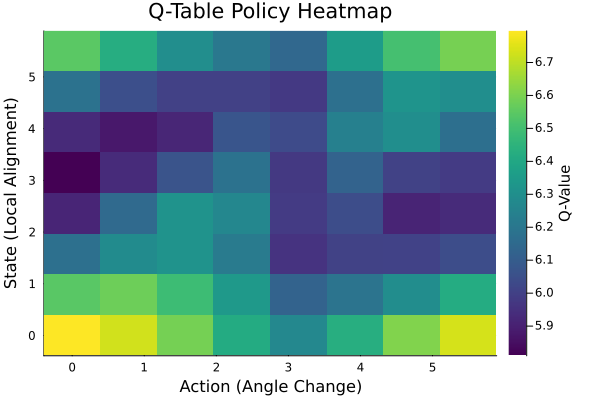

In [52]:
# Generate the heatmap
heatmap(
    actions,            # X-axis: The possible moves (Δθ)
    states,             # Y-axis: The discrete states (Δϕ)
    Q_rec,              # The 2D matrix data
    title="Q-Table Policy Heatmap",
    xlabel="Action (Angle Change)",
    ylabel="State (Local Alignment)",
    color=:viridis,     # A colorblind-friendly, high-contrast palette
    colorbar_title="Q-Value",
    aspect_ratio=:none, # Allows the plot to stretch to fill the frame
    right_margin=5Plots.mm # Prevents the colorbar from getting cut off
)

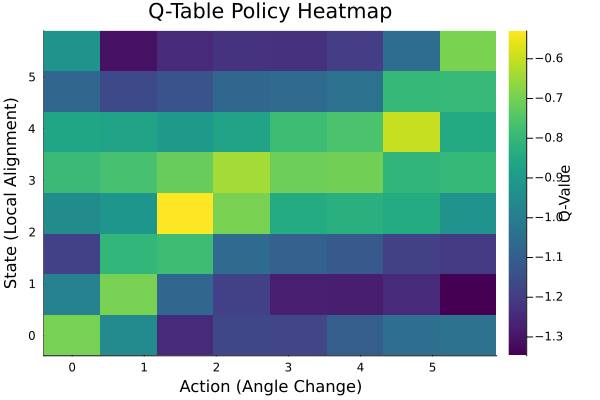

In [54]:
# Generate the heatmap
heatmap(
    actions,            # X-axis: The possible moves (Δθ)
    states,             # Y-axis: The discrete states (Δϕ)
    Q_rec2,              # The 2D matrix data
    title="Q-Table Policy Heatmap",
    xlabel="Action (Angle Change)",
    ylabel="State (Local Alignment)",
    color=:viridis,     # A colorblind-friendly, high-contrast palette
    colorbar_title="Q-Value",
    aspect_ratio=:none, # Allows the plot to stretch to fill the frame
    right_margin=5Plots.mm # Prevents the colorbar from getting cut off
)

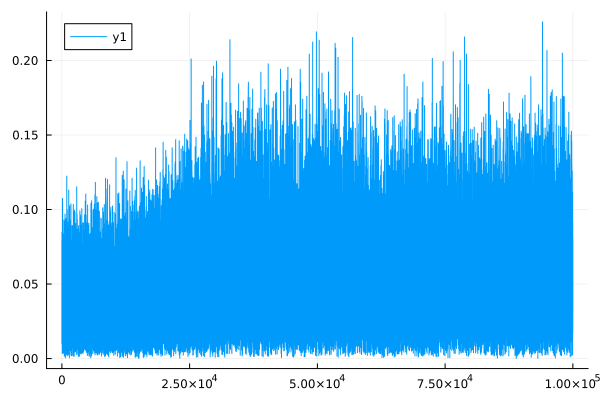

In [55]:
plot(Φ)